<a href="https://colab.research.google.com/github/Majedalansari/traffic-sign-recognition/blob/main/Traffic_Sign_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Sign Recognition Using CNN

This project uses a Convolutional Neural Network (CNN) to classify traffic signs from the GTSRB dataset. The model was trained to recognize 43 different traffic sign classes and achieved approximately 97.4% test accuracy.

## 1. Import Libraries


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## 2. Download and Extract Dataset

In [3]:
!wget -q https://cdn.cs50.net/ai/2023/x/projects/5/gtsrb.zip
!unzip -q gtsrb.zip

In [4]:
import os

print(os.listdir('gtsrb')[:10])

['39', '27', '32', '5', '10', '29', '34', '33', '14', '28']


In [5]:
num_classes = len(os.listdir('gtsrb'))
print("Number of classes:", num_classes)

Number of classes: 43


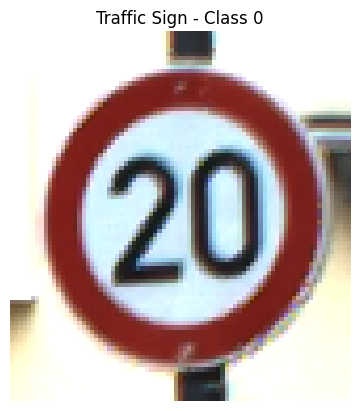

In [6]:
import cv2
import os

class_folder = 'gtsrb/0'
image_name = os.listdir(class_folder)[0]
image = cv2.imread(os.path.join(class_folder, image_name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Traffic Sign - Class 0")
plt.axis('off')
plt.show()

## 3. Load and Preprocess Images

In [7]:
images = []
labels = []

for label in range(43):
    folder = f'gtsrb/{label}'

    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (30, 30))

        images.append(img)
        labels.append(label)

print("Number of images:", len(images))

Number of images: 26640


In [8]:
images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (26640, 30, 30, 3)
Labels shape: (26640,)


## 4. Split the Data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (21312, 30, 30, 3)
Testing: (5328, 30, 30, 3)


## 5. Normalize the Images

In [10]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(X_train.min(), X_train.max())

0.0 1.0


## 6. Build the CNN Model

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu',
                           input_shape=(30, 30, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(43, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile the Model

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 8. Train the Model

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.5570 - loss: 1.6381 - val_accuracy: 0.8433 - val_loss: 0.5311
Epoch 2/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9050 - loss: 0.3528 - val_accuracy: 0.9278 - val_loss: 0.2671
Epoch 3/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.9559 - loss: 0.1674 - val_accuracy: 0.9566 - val_loss: 0.1596
Epoch 4/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.9736 - loss: 0.1069 - val_accuracy: 0.9552 - val_loss: 0.1710
Epoch 5/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.9806 - loss: 0.0729 - val_accuracy: 0.9606 - val_loss: 0.1461
Epoch 6/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.9845 - loss: 0.0561 - val_accuracy: 0.9730 - val_loss: 0.1152
Epoch 7/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9889 - loss: 0.0403 - val_accuracy: 0.9594 - val_loss: 0.1541
Epoch 8/10
533/533 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.9879 - loss: 0.0467 - 

## 9. Evaluate the Model

In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9739 - loss: 0.1132
Test Accuracy: 0.9739114046096802
Test Loss: 0.11319124698638916


## 10. Test a Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step


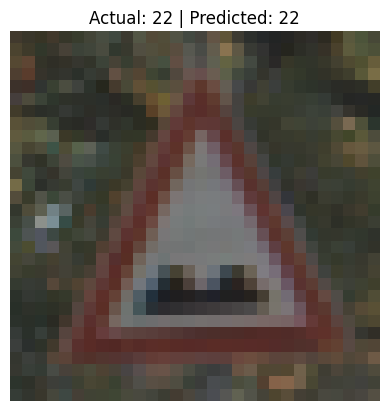

In [16]:
index = 0

prediction = model.predict(X_test[index:index+1])
predicted_class = np.argmax(prediction)

plt.imshow(X_test[index])
plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_class}")
plt.axis('off')
plt.show()

## 11. Save the Model

In [17]:
model.save('traffic_sign_model.keras')
print("Model saved successfully!")

Model saved successfully!
